# Assignment-2 COMP-5970 Jacob Murrah
## README
This assignment involves two mini-projects crafted to enhance your skills in image transformations and visual reasoning. Each is framed as a puzzle where you work through tasks like mapping, warping, projecting, and manipulating images to achieve precise results and build intuition.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **opencv-python**
- **ipython**
- **scikit-image**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

## GenAI Usage Declaration
GenAI was used to explain the basics of SIFT, RANSAC, keypoint detection, and perspective transformations.

## Statement of Contribution
This was an individual project and I did everything in it.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

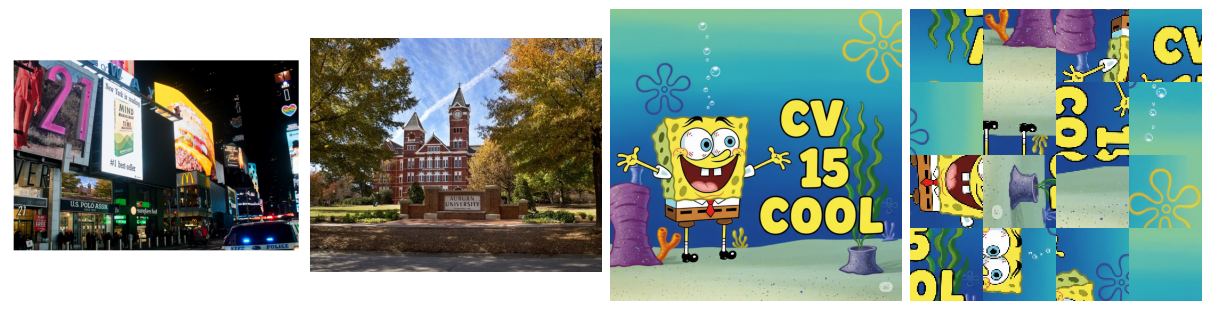

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import io
from skimage import color as change
import cv2
from IPython.display import Image
import math


# Loading images
np.set_printoptions(precision=2)

scene = cv2.cvtColor(
    cv2.imread('Part1_scene.png'), cv2.COLOR_BGR2RGB
)
auburn = cv2.cvtColor(
    cv2.imread('auburn.jpeg'), cv2.COLOR_BGR2RGB
)
puzzle_ref = cv2.cvtColor(
    cv2.imread('puzzle_reference.png'), cv2.COLOR_BGR2RGB
)
puzzle_scr = cv2.cvtColor(
    cv2.imread('puzzle_scrambled.png'), cv2.COLOR_BGR2RGB
)


fig, axes = plt.subplots(1, 4, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(scene)
axes[0].axis('off')
axes[1].imshow(auburn)
axes[1].axis('off')
axes[2].imshow(puzzle_ref)
axes[2].axis('off')
axes[3].imshow(puzzle_scr)
axes[3].axis('off')

# PART 1) Localize a Hidden Object in the Scene
Your goal is to automatically find a hidden object (e.g., an image of Samford
Hall) in a real-world scene using feature matching. Then, using geometric
reasoning, you will highlight where the object appears in the scene.

## Description of Approach
abc

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
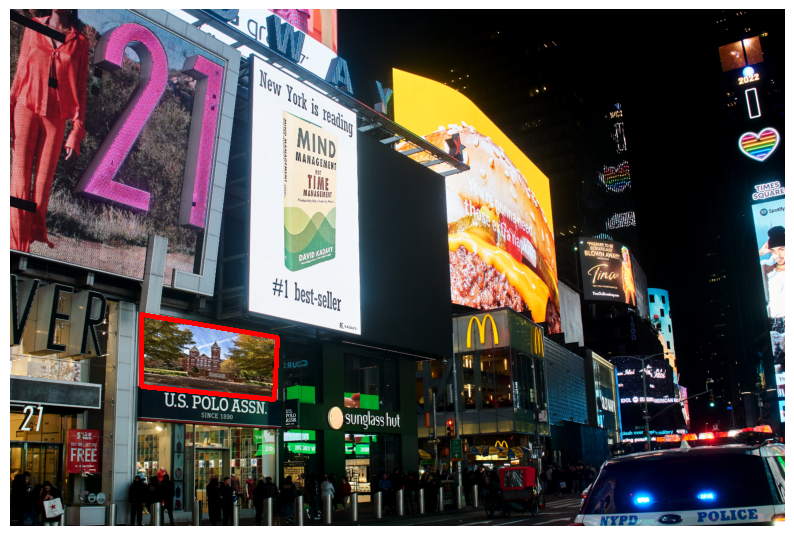

In [38]:
scene_gray = cv2.cvtColor(scene, cv2.COLOR_RGB2GRAY)
auburn_gray = cv2.cvtColor(auburn, cv2.COLOR_RGB2GRAY)

# SIFT
sift = cv2.SIFT_create()
kp_scene, des_scene = sift.detectAndCompute(scene_gray, None)
kp_auburn, des_auburn = sift.detectAndCompute(auburn_gray, None)

# FLANN
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des_scene, des_auburn, k=2)

# Lowe's ratio test
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]

# RANSAC
src_pts = np.float32(
    [kp_scene[m.queryIdx].pt for m in good_matches]
).reshape(-1, 1, 2)
dst_pts = np.float32(
    [kp_auburn[m.trainIdx].pt for m in good_matches]
).reshape(-1, 1, 2)
H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
height, width = scene.shape[:2]
warped_img = cv2.warpPerspective(auburn, H, (width, height))

# Perspective transform
auburn_h, auburn_w = auburn.shape[:2]
auburn_corners = np.float32(
    [
        [0, 0],
        [auburn_w - 1, 0],
        [auburn_w - 1, auburn_h - 1],
        [0, auburn_h - 1]
    ]
).reshape(-1, 1, 2)
projected_corners = cv2.perspectiveTransform(auburn_corners, H)
cv2.polylines(
    scene.copy(),
    [np.int32(projected_corners)],
    True,
    (255, 0, 0), # NOTE: Bounding box is in RED!
    3
)

The bounding box around Samford hall is in RED!

# PART 2) Geometric Puzzle Solver v2
In the previous assignment, you manually tested combinations of
transformations (rotation, flipping) to piece together the correct image. This
time, you will automatically identify the correct orientation and location of
each tile by matching it to the original image using SIFT features and
homography.

## Description of Approach
abc

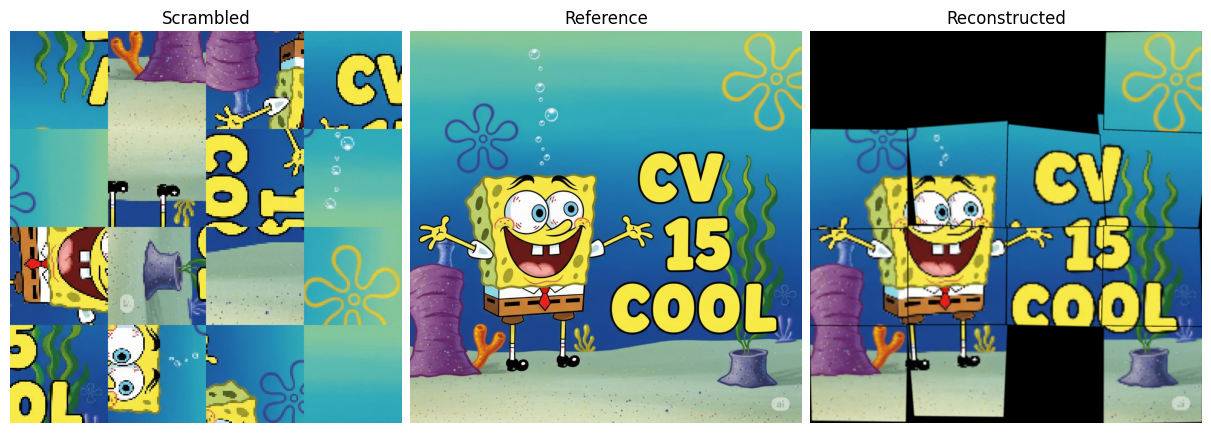

In [49]:
# SIFT
SIFT = cv2.SIFT_create(
    nfeatures=0,
    nOctaveLayers=6,
    contrastThreshold=0.01,
    edgeThreshold=100,
    sigma=1.6
)

def get_homography_H(kp_src, des_src, kp_dest, des_dest):
    # FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=200)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des_src, des_dest, k=2)

    # Lowe's ratio test
    good_matches = [m for m, n in matches if m.distance < 0.8 * n.distance]
    if len(good_matches) < 4:
        return None, None

    # RANSAC
    src_pts = np.float32(
        [kp_src[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    dst_pts = np.float32(
        [kp_dest[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    if H is None:
        return None, None

    mask = mask.ravel()
    inliers = int(np.count_nonzero(mask))
    if inliers < 4:
        return None, None

    return H, inliers


output = np.zeros_like(puzzle_ref)
ref_gray = cv2.cvtColor(puzzle_ref, cv2.COLOR_RGB2GRAY)
kp_ref, des_ref = SIFT.detectAndCompute(ref_gray, None)

placed_mask = np.zeros((puzzle_ref.shape[0], puzzle_ref.shape[1]), dtype=bool)
for i, tile_row_start in enumerate(range(0, 256, 64)):
    for j, tile_col_start in enumerate(range(0, 256, 64)):
        tile_scr = puzzle_scr[
            tile_row_start:tile_row_start+64,
            tile_col_start:tile_col_start+64,
            :
        ]

        # NOTE: SIFT is NOT flip-invariant
        variants = [
            tile_scr,
            cv2.flip(tile_scr, 0),
            cv2.flip(tile_scr, 1),
            cv2.flip(tile_scr, -1),
        ]

        best_variant = None
        for tile_var in variants:
            scr_gray = cv2.cvtColor(tile_var, cv2.COLOR_RGB2GRAY)
            kp_scr, des_scr = SIFT.detectAndCompute(scr_gray, None)
            if des_scr is None or len(kp_scr) < 4:
                continue

            H, inliers = get_homography_H(kp_scr, des_scr, kp_ref, des_ref)
            if H is None:
                continue

            if best_variant is None or inliers > best_variant[1]:
                best_variant = (H, inliers, tile_var)

        if best_variant is None:
            continue

        H, inliers, tile_var = best_variant
        warped = cv2.warpPerspective(
            tile_var,
            H,
            (output.shape[1], output.shape[0])
        )
        mask = np.any(warped != 0, axis=2)

        output[mask] = warped[mask]
        placed_mask |= mask

fig, axes = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True)
axes[0].imshow(puzzle_scr)
axes[0].set_title("Scrambled")
axes[0].axis('off')
axes[1].imshow(puzzle_ref)
axes[1].set_title("Reference")
axes[1].axis('off')
axes[2].imshow(output)
axes[2].set_title("Reconstructed")
axes[2].axis('off')
plt.show()